# Retrieval Stack Test Bench

An offline-first, reader-facing notebook that executes the production retrieval pipeline:

`query_processor -> dense + sparse -> HybridRetriever (RRF) -> CrossEncoderReranker -> MMRSampler`

**How to use it:** edit the parameters in **Setup**, then run all cells. The default path is deterministic and requires neither a Qdrant server nor a model download. Set `RUN_OPTIONAL_MODEL=True` only for a real cross-encoder smoke test.

## Navigation

- [1. Goal and test matrix](#1.-Goal-and-test-matrix)
- [2. Setup](#2.-Setup)
- [3. Component readiness](#3.-Component-readiness)
- [4. Query processor](#4.-Query-processor)
- [5. Dense retrieval](#5.-Dense-retrieval)
- [6. Sparse retrieval](#6.-Sparse-retrieval)
- [7. Hybrid RRF fusion](#7.-Hybrid-RRF-fusion)
- [8. Cross-encoder reranking](#8.-Cross-encoder-reranking)
- [9. MMR diversity](#9.-MMR-diversity)
- [10. Retriever factory](#10.-Retriever-factory)
- [11. End-to-end rank flow](#11.-End-to-end-rank-flow)
- [12. Test summary](#12.-Test-summary)

## 1. Goal and test matrix

This is a **diagnostic and integration test notebook**, not a second implementation of the retrieval package. Every retrieval stage below calls its production class with deterministic local fixtures.

| Component | Production target | What this notebook checks |
|---|---|---|
| Query processing | `retrieval/query_processor.py` | cleaning, technical-token preservation, bounded expansion |
| Dense retrieval | `retrieval/dense_retriever.py` | embedding, Qdrant request contract, filters, ordering, health |
| Sparse retrieval | `retrieval/sparse_retriever.py` | BM25 build/load/search, metadata filters, artifact integrity |
| Hybrid retrieval | `retrieval/hybrid_retriever.py` | production RRF fusion, deduplication, ordering |
| Reranking | `retrieval/reranker.py` | production pair construction, scoring, stable reranking |
| MMR | `retrieval/mmr_sampler.py` | production relevance/diversity selection |
| Factory | `retrieval/retriever_factory.py` | dense, sparse, nested hybrid construction and execution |
| Pipeline | all modules | factory-built hybrid -> reranker -> MMR integration |

### Key assumptions

- The fake Qdrant collection mirrors the production cosine/payload contract without requiring a server.
- Dense and sparse raw scores are deliberately incompatible; RRF uses rank positions only.
- The fake cross-encoder and embedder test production orchestration without network access.
- `RUN_OPTIONAL_MODEL=True` may download `cross-encoder/ms-marco-MiniLM-L-6-v2`.

## 2. Setup

Edit only this parameter cell for routine experiments.

In [1]:
from __future__ import annotations

import importlib
import importlib.util
import math
import os
import sys
import tempfile
import time
import types
from dataclasses import asdict
from pathlib import Path
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_colwidth", 100)
np.set_printoptions(precision=3, suppress=True)


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "retrieval").is_dir() and (candidate / "processing").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate the project root from the notebook working directory")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Experiment parameters
QUERY = "How does RAG combine BM25 and dense retrieval?"
TOP_K = 4
RRF_K = 60
MMR_LAMBDA = 0.40
MMR_TOP_K = 3
ENABLE_QUERY_EXPANSION = True
RUN_OPTIONAL_MODEL = False  # True may download cross-encoder/ms-marco-MiniLM-L-6-v2

print(f"Project root: {PROJECT_ROOT}")
print(f"Query: {QUERY!r}")

Project root: D:\data science\project\RAG-AI_Reasearch_Papers
Query: 'How does RAG combine BM25 and dense retrieval?'


### Test recorder

All sections write to one bounded summary table.

In [2]:
checks = []


def record_check(component, check, passed, detail="", status=None):
    resolved_status = status or ("PASS" if passed else "FAIL")
    checks.append({
        "component": component,
        "check": check,
        "status": resolved_status,
        "detail": str(detail)[:240],
    })


def result_table(results, limit=TOP_K):
    return pd.DataFrame([
        {
            "rank": rank,
            "chunk_id": item.chunk_id,
            "source": item.source,
            "score": round(float(item.score), 5),
            "section": item.section,
            "text": item.text[:110],
        }
        for rank, item in enumerate(results[:limit], 1)
    ])

## 3. Component readiness

This section separates missing packages, missing production modules, and runnable code.

In [3]:
dependency_names = ["numpy", "pandas", "matplotlib", "rank_bm25", "qdrant_client", "sentence_transformers"]
dependency_rows = []
for name in dependency_names:
    available = importlib.util.find_spec(name) is not None
    dependency_rows.append({"dependency": name, "available": available})

dependency_status = pd.DataFrame(dependency_rows)
display(dependency_status.style.map(lambda value: "color: #14833b" if value is True else "color: #a15c00"))

,dependency,available
0,numpy,True
1,pandas,True
2,matplotlib,True
3,rank_bm25,True
4,qdrant_client,True
5,sentence_transformers,True


### Offline BM25 compatibility

If `rank-bm25` is missing, install the declared project dependency for normal use:

```bash
python -m pip install rank-bm25==0.2.2
```

For this notebook only, the following minimal compatible class keeps production query/sparse code testable. It does **not** hide the missing dependency in the table above.

In [4]:
USING_BM25_FALLBACK = importlib.util.find_spec("rank_bm25") is None

if USING_BM25_FALLBACK:
    fallback_module = types.ModuleType("rank_bm25")

    class BM25Okapi:
        def __init__(self, corpus, k1=1.5, b=0.75, epsilon=0.25):
            self.corpus = [list(document) for document in corpus]
            self.k1, self.b, self.epsilon = k1, b, epsilon
            self.doc_len = np.asarray([len(document) for document in self.corpus], dtype=float)
            self.avgdl = float(self.doc_len.mean()) if len(self.doc_len) else 0.0
            self.doc_freqs = []
            document_frequency = {}
            for document in self.corpus:
                frequencies = {}
                for token in document:
                    frequencies[token] = frequencies.get(token, 0) + 1
                self.doc_freqs.append(frequencies)
                for token in frequencies:
                    document_frequency[token] = document_frequency.get(token, 0) + 1
            corpus_size = max(len(self.corpus), 1)
            raw_idf = {
                token: math.log(corpus_size - frequency + 0.5) - math.log(frequency + 0.5)
                for token, frequency in document_frequency.items()
            }
            positive = [value for value in raw_idf.values() if value >= 0]
            average_idf = sum(positive) / len(positive) if positive else 0.0
            self.idf = {
                token: value if value >= 0 else epsilon * average_idf
                for token, value in raw_idf.items()
            }

        def get_scores(self, query_tokens):
            scores = np.zeros(len(self.corpus), dtype=float)
            if not len(self.corpus):
                return scores
            normalization = self.k1 * (1 - self.b + self.b * self.doc_len / max(self.avgdl, 1e-12))
            for token in query_tokens:
                frequencies = np.asarray([document.get(token, 0) for document in self.doc_freqs], dtype=float)
                scores += self.idf.get(token, 0.0) * frequencies * (self.k1 + 1) / (frequencies + normalization)
            return scores

    fallback_module.BM25Okapi = BM25Okapi
    sys.modules["rank_bm25"] = fallback_module

record_check(
    "environment",
    "rank-bm25 dependency",
    not USING_BM25_FALLBACK,
    "Installed" if not USING_BM25_FALLBACK else "Missing; notebook compatibility fallback activated",
    status="PASS" if not USING_BM25_FALLBACK else "WARN",
)
print("BM25 backend:", "notebook fallback" if USING_BM25_FALLBACK else "rank-bm25 package")

BM25 backend: rank-bm25 package


In [5]:
production_modules = {
    "query": "retrieval.query_processor",
    "dense": "retrieval.dense_retriever",
    "sparse": "retrieval.sparse_retriever",
    "hybrid": "retrieval.hybrid_retriever",
    "reranker": "retrieval.reranker",
    "mmr": "retrieval.mmr_sampler",
    "factory": "retrieval.retriever_factory",
}

module_rows = []
for component, module_name in production_modules.items():
    available = importlib.util.find_spec(module_name) is not None
    module_rows.append({"component": component, "module": module_name, "production_available": available})
    record_check(component, "production module present", available, module_name)

display(pd.DataFrame(module_rows).style.map(
    lambda value: "color: #14833b" if value is True else "color: #c62828"
))

from processing.bm25_indexer import BM25Indexer
from processing.chunker import Chunk
from retrieval import (
    CrossEncoderReranker,
    DenseRetriever,
    HybridRetriever,
    MMRSampler,
    QueryProcessor,
    SparseRetriever,
    build_retriever,
)

,component,module,production_available
0,query,retrieval.query_processor,True
1,dense,retrieval.dense_retriever,True
2,sparse,retrieval.sparse_retriever,True
3,hybrid,retrieval.hybrid_retriever,True
4,reranker,retrieval.reranker,True
5,mmr,retrieval.mmr_sampler,True
6,factory,retrieval.retriever_factory,True


### Shared deterministic fixture

In [6]:
fixture_chunks = [
    Chunk("c-rag", "p-rag", "abstract", "retrieval augmented generation grounds answers with evidence", 0, 60,
          {"title": "Grounded RAG", "year": 2024, "category": "cs.CL"}),
    Chunk("c-bm25", "p-bm25", "method", "BM25 lexical keyword search provides sparse retrieval", 0, 53,
          {"title": "Lexical Search", "year": 2021, "category": "cs.IR"}),
    Chunk("c-dense", "p-dense", "method", "dense semantic vector similarity retrieves paraphrases", 0, 54,
          {"title": "Semantic Search", "year": 2023, "category": "cs.IR"}),
    Chunk("c-hybrid", "p-hybrid", "results", "hybrid retrieval fuses BM25 and dense ranks with reciprocal rank fusion", 0, 71,
          {"title": "Hybrid Retrieval", "year": 2025, "category": "cs.CL"}),
    Chunk("c-vision", "p-vision", "abstract", "vision transformer image classification benchmark", 0, 49,
          {"title": "Vision Models", "year": 2022, "category": "cs.CV"}),
]
print(f"Fixture: {len(fixture_chunks)} chunks")

Fixture: 5 chunks


## 4. Query processor

Exercise production cleaning, sparse tokenization, and optional expansion.

In [7]:
query_processor = QueryProcessor(enable_expansion=ENABLE_QUERY_EXPANSION)
query_cases = [
    "  GPT-4\tC++  F1-score\nLLaMA-3 Q-learning  ",
    QUERY,
    "RAG evaluation",
]
processed_rows = []
for raw_query in query_cases:
    processed = query_processor.process(raw_query)
    processed_rows.append({
        "original": raw_query.replace("\n", "\\n").replace("\t", "\\t"),
        "cleaned": processed.cleaned_query,
        "dense_query": processed.dense_query,
        "sparse_tokens": processed.sparse_tokens,
        "expanded": processed.expanded_query,
    })

display(pd.DataFrame(processed_rows))
technical = query_processor.process(query_cases[0])
expected_terms = {"gpt-4", "c++", "f1-score", "llama-3", "q-learning"}
record_check("query", "technical tokens preserved", expected_terms.issubset(set(technical.sparse_tokens)), technical.sparse_tokens)
record_check("query", "whitespace normalized", technical.cleaned_query == "GPT-4 C++ F1-score LLaMA-3 Q-learning", technical.cleaned_query)
expanded = query_processor.process("RAG evaluation")
record_check("query", "bounded expansion retains original", expanded.dense_query.startswith("RAG evaluation"), expanded.dense_query)

,original,cleaned,dense_query,sparse_tokens,expanded
0,GPT-4\tC++ F1-score\nLLaMA-3 Q-learning,GPT-4 C++ F1-score LLaMA-3 Q-learning,GPT-4 C++ F1-score LLaMA-3 Q-learning,"[gpt-4, c++, f1-score, llama-3, q-learning]",GPT-4 C++ F1-score LLaMA-3 Q-learning
1,How does RAG combine BM25 and dense retrieval?,How does RAG combine BM25 and dense retrieval?,How does RAG combine BM25 and dense retrieval? retrieval augmented generation best matching 25 l...,"[how, does, rag, combine, bm25, and, dense, retrieval, retrieval, augmented, generation, best, m...",How does RAG combine BM25 and dense retrieval? retrieval augmented generation best matching 25 l...
2,RAG evaluation,RAG evaluation,RAG evaluation retrieval augmented generation assessment benchmarking,"[rag, evaluation, retrieval, augmented, generation, assessment, benchmarking]",RAG evaluation retrieval augmented generation assessment benchmarking


## 5. Dense retrieval

Use a fake Qdrant client to test the production request/response contract without a server or model download.

In [8]:
class FakeEmbedder:
    dimension = 3

    def encode_texts(self, texts):
        return np.asarray([[0.2, 0.7, 0.1] for _ in texts], dtype=float)


class FakeQdrantClient:
    def __init__(self):
        self.last_query = None

    def collection_exists(self, name):
        return name == "test-papers"

    def get_collection(self, name):
        return SimpleNamespace(
            points_count=3,
            status=SimpleNamespace(value="green"),
            config=SimpleNamespace(params=SimpleNamespace(vectors=SimpleNamespace(
                size=3, distance=SimpleNamespace(value="Cosine")
            ))),
        )

    def query_points(self, **kwargs):
        self.last_query = kwargs
        return SimpleNamespace(points=[
            SimpleNamespace(id="c-dense", score=0.91, payload=fixture_chunks[2].to_dict()),
            SimpleNamespace(id="c-hybrid", score=0.86, payload=fixture_chunks[3].to_dict()),
            SimpleNamespace(id="c-rag", score=0.72, payload=fixture_chunks[0].to_dict()),
        ])


fake_qdrant = FakeQdrantClient()
dense_retriever = DenseRetriever(fake_qdrant, FakeEmbedder(), "test-papers", default_top_k=TOP_K)
dense_health = dense_retriever.health_check()
dense_start = time.perf_counter()
dense_results = dense_retriever.search(
    query_processor.process(QUERY).dense_query,
    top_k=TOP_K,
    filters={"year": {"gte": 2020}, "section": ["abstract", "method", "results"]},
)
dense_latency_ms = (time.perf_counter() - dense_start) * 1000

display(pd.Series(dense_health, name="value").to_frame())
display(result_table(dense_results))
record_check("dense", "cosine collection is healthy", dense_health["distance"].casefold() == "cosine", dense_health)
record_check("dense", "dimension matches", dense_health["dimension_match"] is True, dense_health)
record_check("dense", "results sorted descending", [r.score for r in dense_results] == sorted([r.score for r in dense_results], reverse=True), [r.score for r in dense_results])
record_check("dense", "Qdrant filter forwarded", fake_qdrant.last_query.get("query_filter") is not None, type(fake_qdrant.last_query.get("query_filter")).__name__)

,value
connected,True
collection_exists,True
collection_name,test-papers
points_count,3
vector_size,3
distance,Cosine
collection_status,green
embedder_dimension,3
dimension_match,True


,rank,chunk_id,source,score,section,text
0,1,c-dense,dense,0.91,method,dense semantic vector similarity retrieves paraphrases
1,2,c-hybrid,dense,0.86,results,hybrid retrieval fuses BM25 and dense ranks with reciprocal rank fusion
2,3,c-rag,dense,0.72,abstract,retrieval augmented generation grounds answers with evidence


## 6. Sparse retrieval

Build a temporary trusted BM25 artifact, then exercise the production retriever.

In [9]:
bm25_tempdir = tempfile.TemporaryDirectory()
index_path = Path(bm25_tempdir.name) / "bm25_fixture.pkl"
indexer = BM25Indexer()
indexer.build(fixture_chunks)
indexer.save(index_path)

sparse_retriever = SparseRetriever(index_path, default_top_k=TOP_K)
sparse_start = time.perf_counter()
sparse_results = sparse_retriever.search(
    query_processor.process(QUERY).sparse_tokens,
    top_k=TOP_K,
)
sparse_latency_ms = (time.perf_counter() - sparse_start) * 1000
sparse_filtered = sparse_retriever.search("retrieval", filters={"year": {"gte": 2024}})
sparse_health = sparse_retriever.health_check()

display(pd.Series(sparse_health, name="value").to_frame())
display(result_table(sparse_results))
record_check("sparse", "artifact mapping valid", sparse_health["mapping_valid"] is True, sparse_health)
record_check("sparse", "results sorted descending", [r.score for r in sparse_results] == sorted([r.score for r in sparse_results], reverse=True), [round(r.score, 4) for r in sparse_results])
record_check("sparse", "year filter applied", all((r.year or 0) >= 2024 for r in sparse_filtered), [r.year for r in sparse_filtered])

,value
loaded,True
index_path,C:\Users\hp\AppData\Local\Temp\tmpv3urv_9r\bm25_fixture.pkl
document_count,5
chunk_mapping_count,5
metadata_count,5
mapping_valid,True
preprocessing_config,"{'tokenizer': 'technical_terms_v2', 'lowercase': True, 'stop_words_removed': False}"
version,2.0
created_at,2026-07-27T15:56:52.302690+00:00


,rank,chunk_id,source,score,section,text
0,1,c-rag,sparse,2.96825,abstract,retrieval augmented generation grounds answers with evidence
1,2,c-bm25,sparse,2.19646,method,BM25 lexical keyword search provides sparse retrieval
2,3,c-hybrid,sparse,2.02463,results,hybrid retrieval fuses BM25 and dense ranks with reciprocal rank fusion
3,4,c-dense,sparse,0.36375,method,dense semantic vector similarity retrieves paraphrases


## 7. Hybrid RRF fusion

`HybridRetriever` calls both production backends and combines rank positions. Duplicate chunk IDs contribute once per backend, and raw cosine/BM25 score scales are never compared.

In [10]:
hybrid_retriever = HybridRetriever(
    dense_retriever,
    sparse_retriever,
    rrf_k=RRF_K,
    default_top_k=TOP_K,
    candidate_top_k=TOP_K,
)
hybrid_start = time.perf_counter()
hybrid_results = hybrid_retriever.search(QUERY, top_k=TOP_K)
hybrid_latency_ms = (time.perf_counter() - hybrid_start) * 1000
hybrid_health = hybrid_retriever.health_check()

display(result_table(hybrid_results, limit=10))
overlap_ids = {item.chunk_id for item in dense_results} & {item.chunk_id for item in sparse_results}
record_check("hybrid", "production class executed", all(item.source == "hybrid" for item in hybrid_results), type(hybrid_retriever).__name__)
record_check("hybrid", "RRF output sorted", [r.score for r in hybrid_results] == sorted([r.score for r in hybrid_results], reverse=True), [round(r.score, 5) for r in hybrid_results])
record_check("hybrid", "duplicate chunks fused", len(hybrid_results) == len({r.chunk_id for r in hybrid_results}), f"backend overlap={sorted(overlap_ids)}")
record_check("hybrid", "multi-list evidence retained", overlap_ids.issubset({r.chunk_id for r in hybrid_results}), sorted(overlap_ids))
record_check("hybrid", "both backends healthy", hybrid_health["healthy"] is True, hybrid_health)

,rank,chunk_id,source,score,section,text
0,1,c-hybrid,hybrid,0.03252,results,hybrid retrieval fuses BM25 and dense ranks with reciprocal rank fusion
1,2,c-dense,hybrid,0.03227,method,dense semantic vector similarity retrieves paraphrases
2,3,c-rag,hybrid,0.03150,abstract,retrieval augmented generation grounds answers with evidence
3,4,c-bm25,hybrid,0.01613,method,BM25 lexical keyword search provides sparse retrieval


## 8. Cross-encoder reranking

`CrossEncoderReranker` receives an injected deterministic model by default, exercising the production `(query, passage)` scoring and result-copying contract. Enable the optional model only when download/cache access is acceptable.

In [11]:
class FakeCrossEncoder:
    def __init__(self):
        self.last_pairs = []

    def predict(self, pairs):
        self.last_pairs = list(pairs)
        query_terms = set(pairs[0][0].casefold().replace("?", "").split()) if pairs else set()
        return np.asarray([
            len(query_terms & set(passage.casefold().replace("?", "").split())) + 0.01 * len(passage)
            for _, passage in pairs
        ], dtype=float)


fake_cross_encoder = FakeCrossEncoder()
reranker = CrossEncoderReranker(model=fake_cross_encoder, default_top_k=TOP_K)
rerank_start = time.perf_counter()
reranked_results = reranker.rerank(QUERY, hybrid_results, top_k=TOP_K)
rerank_latency_ms = (time.perf_counter() - rerank_start) * 1000

display(result_table(reranked_results))
record_check("reranker", "one pair per candidate", len(fake_cross_encoder.last_pairs) == len(hybrid_results), len(fake_cross_encoder.last_pairs))
record_check("reranker", "query paired with every passage", all(pair[0] == QUERY for pair in fake_cross_encoder.last_pairs), fake_cross_encoder.last_pairs)
record_check("reranker", "scores sorted descending", [r.score for r in reranked_results] == sorted([r.score for r in reranked_results], reverse=True), [round(r.score, 3) for r in reranked_results])
record_check("reranker", "source updated", all(r.source == "reranked" for r in reranked_results), [r.source for r in reranked_results])

if RUN_OPTIONAL_MODEL:
    if importlib.util.find_spec("sentence_transformers") is None:
        record_check("reranker", "real model smoke test", False, "sentence-transformers is not installed", status="SKIP")
    else:
        real_reranker = CrossEncoderReranker(default_top_k=TOP_K)
        real_results = real_reranker.rerank(QUERY, hybrid_results, top_k=TOP_K)
        record_check("reranker", "real model smoke test", len(real_results) == min(TOP_K, len(hybrid_results)), [round(r.score, 3) for r in real_results])
else:
    record_check("reranker", "real model smoke test", False, "Disabled by RUN_OPTIONAL_MODEL=False", status="SKIP")

,rank,chunk_id,source,score,section,text
0,1,c-hybrid,reranked,4.71,results,hybrid retrieval fuses BM25 and dense ranks with reciprocal rank fusion
1,2,c-bm25,reranked,2.53,method,BM25 lexical keyword search provides sparse retrieval
2,3,c-rag,reranked,1.60,abstract,retrieval augmented generation grounds answers with evidence
3,4,c-dense,reranked,1.54,method,dense semantic vector similarity retrieves paraphrases


## 9. MMR diversity

`MMRSampler` uses the production MMR function. The deterministic embeddings contain two near-duplicates and one relevant but diverse candidate, making the diversity decision inspectable.

In [12]:
class FakeMMREmbedder:
    def encode_texts(self, texts):
        vectors = np.asarray([
            [1.00, 0.00, 0.00],  # query
            [1.00, 0.05, 0.00],  # most relevant
            [0.98, 0.08, 0.00],  # near duplicate
            [0.70, 0.10, 0.65],  # relevant and diverse
            [0.97, 0.10, 0.00],  # another near duplicate
        ], dtype=float)
        return vectors[:len(texts)]


mmr_sampler = MMRSampler(FakeMMREmbedder(), lambda_mult=MMR_LAMBDA, default_top_k=MMR_TOP_K)
mmr_results = mmr_sampler.sample(QUERY, reranked_results, top_k=min(MMR_TOP_K, len(reranked_results)))
selected_positions = [reranked_results.index(item) for item in mmr_results]

display(pd.DataFrame({
    "selection_order": range(1, len(selected_positions) + 1),
    "original_rank": [index + 1 for index in selected_positions],
    "chunk_id": [item.chunk_id for item in mmr_results],
}))
record_check("mmr", "production sampler executed", isinstance(mmr_sampler, MMRSampler), type(mmr_sampler).__name__)
record_check("mmr", "selection is unique", len(selected_positions) == len(set(selected_positions)), selected_positions)
record_check("mmr", "top relevant candidate retained", bool(selected_positions) and selected_positions[0] == 0, selected_positions)
record_check("mmr", "diverse candidate selected before near duplicates", len(selected_positions) < 2 or selected_positions[1] == 2, selected_positions)

,selection_order,original_rank,chunk_id
0,1,1,c-hybrid
1,2,3,c-rag
2,3,2,c-bm25


## 10. Retriever factory

Build every supported retriever type from configuration. The hybrid case uses nested dense/sparse configuration and then performs a real search through the resulting object graph.

In [13]:
factory_matrix = pd.DataFrame([
    {"type": "dense", "requires": "qdrant_client, embedder, collection_name", "expected_class": "DenseRetriever"},
    {"type": "sparse", "requires": "index_path", "expected_class": "SparseRetriever"},
    {"type": "hybrid", "requires": "dense + sparse config, rrf_k", "expected_class": "HybridRetriever"},
])
display(factory_matrix)

factory_dense = build_retriever(
    {"type": "dense", "collection_name": "test-papers", "default_top_k": TOP_K},
    qdrant_client=fake_qdrant,
    embedder=FakeEmbedder(),
)
factory_sparse = build_retriever(
    {"type": "sparse", "index_path": index_path, "default_top_k": TOP_K}
)
factory_hybrid = build_retriever(
    {
        "type": "hybrid",
        "rrf_k": RRF_K,
        "default_top_k": TOP_K,
        "candidate_top_k": TOP_K,
        "dense": {"collection_name": "test-papers", "default_top_k": TOP_K},
        "sparse": {"index_path": index_path, "default_top_k": TOP_K},
    },
    qdrant_client=fake_qdrant,
    embedder=FakeEmbedder(),
)
factory_hybrid_results = factory_hybrid.search(QUERY, top_k=TOP_K)

built = {"dense": factory_dense, "sparse": factory_sparse, "hybrid": factory_hybrid}
for kind, retriever in built.items():
    expected = factory_matrix.set_index("type").loc[kind, "expected_class"]
    record_check("factory", f"build {kind}", type(retriever).__name__ == expected, type(retriever).__name__)
record_check("factory", "nested hybrid executes", bool(factory_hybrid_results) and all(r.source == "hybrid" for r in factory_hybrid_results), [r.chunk_id for r in factory_hybrid_results])

try:
    build_retriever({"type": "unsupported"})
except ValueError as error:
    record_check("factory", "invalid type rejected", "unsupported" in str(error), error)
else:
    record_check("factory", "invalid type rejected", False, "No exception raised")

,type,requires,expected_class
0,dense,"qdrant_client, embedder, collection_name",DenseRetriever
1,sparse,index_path,SparseRetriever
2,hybrid,"dense + sparse config, rrf_k",HybridRetriever


## 11. End-to-end rank flow

Run the complete production object graph built by the factory, then show how rank changes after RRF, cross-encoder reranking, and MMR selection.

stage,dense,hybrid_rrf,mmr,reranked,sparse
chunk_id,,,,,
c-bm25,NaN,4.0,3.0,2.0,2.0
c-dense,1.0,2.0,NaN,4.0,4.0
c-hybrid,2.0,1.0,1.0,1.0,3.0
c-rag,3.0,3.0,2.0,3.0,1.0


,rank,chunk_id,source,score,section,text
0,1,c-hybrid,reranked,4.71,results,hybrid retrieval fuses BM25 and dense ranks with reciprocal rank fusion
1,2,c-rag,reranked,1.60,abstract,retrieval augmented generation grounds answers with evidence
2,3,c-bm25,reranked,2.53,method,BM25 lexical keyword search provides sparse retrieval


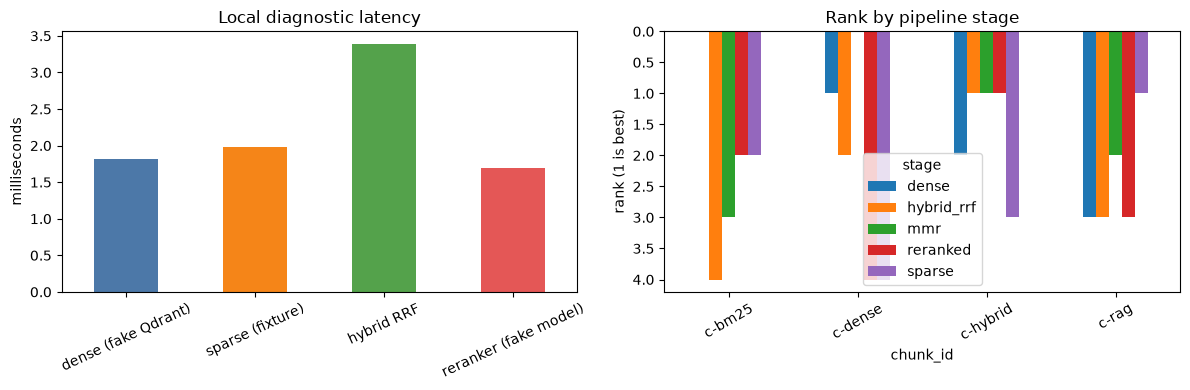

In [14]:
pipeline_hybrid_results = factory_hybrid.search(QUERY, top_k=TOP_K)
pipeline_reranked_results = reranker.rerank(QUERY, pipeline_hybrid_results, top_k=TOP_K)
pipeline_final_results = mmr_sampler.sample(
    QUERY,
    pipeline_reranked_results,
    top_k=min(MMR_TOP_K, len(pipeline_reranked_results)),
)

stage_results = {
    "dense": dense_results,
    "sparse": sparse_results,
    "hybrid_rrf": pipeline_hybrid_results,
    "reranked": pipeline_reranked_results,
    "mmr": pipeline_final_results,
}
rank_rows = []
for stage, results in stage_results.items():
    for rank, item in enumerate(results, 1):
        rank_rows.append({"stage": stage, "rank": rank, "chunk_id": item.chunk_id, "score": item.score})
rank_flow = pd.DataFrame(rank_rows)
rank_pivot = rank_flow.pivot_table(index="chunk_id", columns="stage", values="rank", aggfunc="first")
display(rank_pivot)
display(result_table(pipeline_final_results, limit=MMR_TOP_K))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
latency = pd.Series({
    "dense (fake Qdrant)": dense_latency_ms,
    "sparse (fixture)": sparse_latency_ms,
    "hybrid RRF": hybrid_latency_ms,
    "reranker (fake model)": rerank_latency_ms,
})
latency.plot(kind="bar", ax=axes[0], color=["#4c78a8", "#f58518", "#54a24b", "#e45756"], title="Local diagnostic latency")
axes[0].set_ylabel("milliseconds")
axes[0].tick_params(axis="x", rotation=25)

rank_pivot.plot(kind="bar", ax=axes[1], title="Rank by pipeline stage")
axes[1].invert_yaxis()
axes[1].set_ylabel("rank (1 is best)")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

record_check("pipeline", "factory-built pipeline executed", bool(pipeline_final_results), [r.chunk_id for r in pipeline_final_results])
record_check("pipeline", "final output bounded", len(pipeline_final_results) <= MMR_TOP_K, len(pipeline_final_results))
record_check("pipeline", "final output preserves payloads", all(item.metadata for item in pipeline_final_results), [item.chunk_id for item in pipeline_final_results])

## 12. Test summary

`FAIL` indicates incorrect executable behavior. `WARN` and `SKIP` identify optional environment coverage and do not hide production pipeline failures.

In [15]:
check_table = pd.DataFrame(checks)
status_order = pd.CategoricalDtype(["FAIL", "MISSING", "WARN", "SKIP", "PASS"], ordered=True)
check_table["status"] = check_table["status"].astype(status_order)
check_table = check_table.sort_values(["status", "component", "check"]).reset_index(drop=True)

def color_status(value):
    colors = {"PASS": "#14833b", "FAIL": "#c62828", "MISSING": "#a15c00", "WARN": "#a15c00", "SKIP": "#667085"}
    return f"color: {colors.get(str(value), '#111827')}; font-weight: 600"

display(check_table.style.map(color_status, subset=["status"]))
summary = check_table["status"].astype(str).value_counts().reindex(["PASS", "FAIL", "MISSING", "WARN", "SKIP"], fill_value=0)
display(summary.rename("checks").to_frame())

failures = check_table[check_table["status"].astype(str) == "FAIL"]
missing = check_table[check_table["status"].astype(str) == "MISSING"]
print(f"Executable failures: {len(failures)}")
print(f"Missing production checks: {len(missing)}")
assert failures.empty, failures.to_dict("records")

,component,check,status,detail
0,reranker,real model smoke test,SKIP,Disabled by RUN_OPTIONAL_MODEL=False
1,dense,Qdrant filter forwarded,PASS,Filter
2,dense,cosine collection is healthy,PASS,"{'connected': True, 'collection_exists': True, 'collection_name': 'test-papers', 'points_count': 3, 'vector_size': 3, 'distance': 'Cosine', 'collection_status': 'green', 'embedder_dimension': 3, 'dimension_match': True}"
3,dense,dimension matches,PASS,"{'connected': True, 'collection_exists': True, 'collection_name': 'test-papers', 'points_count': 3, 'vector_size': 3, 'distance': 'Cosine', 'collection_status': 'green', 'embedder_dimension': 3, 'dimension_match': True}"
4,dense,production module present,PASS,retrieval.dense_retriever
5,dense,results sorted descending,PASS,"[0.91, 0.86, 0.72]"
6,environment,rank-bm25 dependency,PASS,Installed
7,factory,build dense,PASS,DenseRetriever
8,factory,build hybrid,PASS,HybridRetriever
9,factory,build sparse,PASS,SparseRetriever


,checks
status,
PASS,39
FAIL,0
MISSING,0
WARN,0
SKIP,1


Executable failures: 0
Missing production checks: 0


### Takeaways

- All default checks execute production retrieval components with deterministic local dependencies.
- The factory-built integration path covers dense + sparse retrieval, RRF fusion, cross-encoder reranking, and MMR sampling.
- The default run is offline. Set `RUN_OPTIONAL_MODEL=True` to smoke-test the real `ms-marco-MiniLM-L-6-v2` cross-encoder when model cache or download access is available.
- Replace `FakeQdrantClient` with a populated Qdrant client to extend the same notebook into a live integration test.